# 앙상블 기법
- 머신러닝 모델을 연결하녀 더 강력한 모델을 만드는 기법
- 하나의 모델은 예측에 오류가 있을수 있으니 여러모델이 함께 판단하면서 더 정교한 예측이 가능

- 앙상블 기반 대표 2가지
  - 베깅: 데이터를 무작위로 나눠서 여러모델을 훈련시킨 후 결과 평균 또는 투표
  - 부스팅: 이전모델이 틀린부분을 다음 모델이 보완하면서 점점 정교하게 학습

##랜덤포레스트
- 배깅 기법을 활용한 대표적인 앙상블 모델
- 장점
  - 예측의 정확도가 높아짐
  - 과적합 방지
  - 변수의 중요도 파악 가능
- 단점
  - 학습 속도가 상대적으로 느린편
  - 수가 많은 트리를 동원하기 때문에 모델에 대한 해속이 어려움

# 중고차 가격 예측하기
- name : 브랜드/모델명
- year : 생산년도
- selling_price : 판매가
- km_driven : 주행거리
- fuel : 연료
- seller_type : 판매자유형
- transmission : 변속기
- owner : 차주변경내역
- mileage : 마일리지
- engine : 배기량
- max_power : 최대출력
- torque : 토크
- seats : 인승

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [2]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/car.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


In [3]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [4]:
round(data.describe(),2)

,year,selling_price,km_driven,seats
count,8128.00,8128.00,8128.00,7907.00
mean,2013.80,638271.81,69819.51,5.42
std,4.04,806253.40,56550.55,0.96
min,1983.00,29999.00,1.00,2.00
25%,2011.00,254999.00,35000.00,5.00
50%,2015.00,450000.00,60000.00,5.00
75%,2017.00,675000.00,98000.00,5.00
max,2020.00,10000000.00,2360457.00,14.00


In [5]:
data[['engine','engine_unit']]=data['engine'].str.split(expand=True)

In [6]:
data['engine'].head()

,engine
0,1248
1,1498
2,1497
3,1396
4,1298


In [7]:
data['engine'] = data['engine'].astype('float32')

In [8]:
data['engine'].head()

,engine
0,1248.0
1,1498.0
2,1497.0
3,1396.0
4,1298.0


In [9]:
data['engine_unit'].unique()

array(['CC', nan], dtype=object)

In [10]:
data.drop(columns=['engine_unit'],inplace=True)

In [11]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248.0,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498.0,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497.0,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396.0,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298.0,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [12]:
data[['max_power','max_power_unit']]=data['max_power'].str.split(expand=True)

In [13]:
data['max_power'].head()

,max_power
0,74
1,103.52
2,78
3,90
4,88.2


In [14]:
def isfloat(value):
  try:
    float(value)
    return float(value) # 실수값 반환
  except ValueError:
    return np.nan # 에러 발생시 Nan값을 반환

In [15]:
data['max_power'] = data['max_power'].apply(isfloat)

In [16]:
data[data['max_power']=='bhp']

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats,max_power_unit


In [17]:
data['max_power'].head()

,max_power
0,74.00
1,103.52
2,78.00
3,90.00
4,88.20


In [18]:
data['max_power_unit'].unique()

array(['bhp', nan, None], dtype=object)

In [19]:
data.drop(columns=['max_power_unit'],inplace=True)

In [20]:
data[['mileage','mileage_unit']]=data['mileage'].str.split(expand=True)

In [21]:
data['mileage'] = data['mileage'].apply('float32')

In [22]:
data['mileage'].head()

,mileage
0,23.400000
1,21.139999
2,17.700001
3,23.000000
4,16.100000


In [23]:
data['mileage_unit'].unique()

array(['kmpl', 'km/kg', nan], dtype=object)

In [24]:
data['fuel'].unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

연료 가격을 활용해서 같은 기준을 만듬  
1달러당 몇 km를 주행할 수 있는지를 판단
- disesl : 리터당 \$73.56
- Petrol : 리터당 \$80.43
- LPG : 킬로그램당 \$40.85
- CNG : 킬로그램당 \$4.23

In [25]:
def mile(x):
  if x['fuel'] == 'petrol':
    return x['mileage']/80.43
  elif x['fuel'] == 'Diesel':
    return x['mileage']/73.56
  elif x['fuel'] =='LPG':
    return x['mileage']/40.85
  else:
    return x['mileage']/44.23

In [26]:
data['mileage'] = data.apply(mile,axis=1)

In [27]:
data['mileage'].head()

,mileage
0,0.318108
1,0.287384
2,0.400181
3,0.312670
4,0.364006


In [28]:
data.drop(columns=['mileage_unit'],inplace=True)

In [29]:
data['torque'].head()

,torque
0,190Nm@ 2000rpm
1,250Nm@ 1500-2500rpm
2,"12.7@ 2,700(kgm@ rpm)"
3,22.4 kgm at 1750-2750rpm
4,"11.5@ 4,500(kgm@ rpm)"


In [30]:
data['torque'] = data['torque'].str.upper()

In [31]:
data['torque'].head()

,torque
0,190NM@ 2000RPM
1,250NM@ 1500-2500RPM
2,"12.7@ 2,700(KGM@ RPM)"
3,22.4 KGM AT 1750-2750RPM
4,"11.5@ 4,500(KGM@ RPM)"


In [32]:
# 단위를 따로 빼내는 작업
# NM, KGM이 있는지를 판별

In [33]:
def torque_unit(x):
  if 'NM' in str(x):
    return 'Nm'
  elif 'KGM' in str(x):
    return 'Kgm'

In [34]:
data['torque_unit'] = data['torque'].apply(torque_unit)

In [35]:
data['torque'].head()

,torque
0,190NM@ 2000RPM
1,250NM@ 1500-2500RPM
2,"12.7@ 2,700(KGM@ RPM)"
3,22.4 KGM AT 1750-2750RPM
4,"11.5@ 4,500(KGM@ RPM)"


In [36]:
data['torque_unit'].unique()

array(['Nm', 'Kgm', None], dtype=object)

In [37]:
data[data['torque_unit'].isna()]['torque'].unique()

array([nan, '250@ 1250-5000RPM', '510@ 1600-2400', '110(11.2)@ 4800',
       '210 / 1900'], dtype=object)

In [38]:
data['torque_unit'].fillna('Nm',inplace=True)

/tmp/ipython-input-3482222137.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['torque_unit'].fillna('Nm',inplace=True)


In [39]:
data[['torque_unit','torque']]

,torque_unit,torque
0,Nm,190NM@ 2000RPM
1,Nm,250NM@ 1500-2500RPM
2,Kgm,"12.7@ 2,700(KGM@ RPM)"
3,Kgm,22.4 KGM AT 1750-2750RPM
4,Kgm,"11.5@ 4,500(KGM@ RPM)"
...,...,...
8123,Nm,113.7NM@ 4000RPM
8124,Kgm,"24@ 1,900-2,750(KGM@ RPM)"
8125,Nm,190NM@ 2000RPM
8126,Nm,140NM@ 1800-3000RPM


In [40]:
def split_num(x):
  x = str(x)
  for i,j in enumerate(x):
    if j not in '0123456789.0':
      cut = i
      break
  return x[:cut]

In [41]:
data['torque'] = data['torque'].apply(split_num)

In [42]:
data['torque']

,torque
0,190
1,250
2,12.7
3,22.4
4,11.5
...,...
8123,113.7
8124,24
8125,190
8126,140


In [43]:
data['torque'] = data['torque'].replace('',np.nan)

In [44]:
data['torque'] = data['torque'].apply('float64')

In [45]:
data['torque'].head()

,torque
0,190.0
1,250.0
2,12.7
3,22.4
4,11.5


In [46]:
# 단위에 따른 차이를 맞춰주는 변환
# Nm , kgm은 중력과 관련괸 것 kgm*98066 = Nm

def trans(x):
  if x['torque_unit'] == 'kgm':
    return x["torque"] * 9.8066
  else:
    return x['torque']
data['torque'] = data.apply(trans,axis=1)

In [47]:
data['torque'].head()

,torque
0,190.0
1,250.0
2,12.7
3,22.4
4,11.5


In [48]:
data.drop(columns=['torque_unit'],inplace=True)

In [49]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,0.318108,1248.0,74.00,190.0,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,0.287384,1498.0,103.52,250.0,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,0.400181,1497.0,78.00,12.7,5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,0.312670,1396.0,90.00,22.4,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,0.364006,1298.0,88.20,11.5,5.0


In [50]:
data['name'] = data['name'].str.split(expand=True)[0]

In [51]:
data['name'].unique()

array(['Maruti', 'Skoda', 'Honda', 'Hyundai', 'Toyota', 'Ford', 'Renault',
       'Mahindra', 'Tata', 'Chevrolet', 'Fiat', 'Datsun', 'Jeep',
       'Mercedes-Benz', 'Mitsubishi', 'Audi', 'Volkswagen', 'BMW',
       'Nissan', 'Lexus', 'Jaguar', 'Land', 'MG', 'Volvo', 'Daewoo',
       'Kia', 'Force', 'Ambassador', 'Ashok', 'Isuzu', 'Opel', 'Peugeot'],
      dtype=object)

In [52]:
data['name'] = data["name"].replace('Land','Land Rover')

In [53]:
data.isnull().mean()

,0
name,0.000000
year,0.000000
selling_price,0.000000
km_driven,0.000000
fuel,0.000000
seller_type,0.000000
transmission,0.000000
owner,0.000000
mileage,0.027190
engine,0.027190


In [54]:
data.dropna(inplace=True)

In [55]:
len(data)

7906

In [56]:
# 남은 텍스츠 컬럼을 더미변수로 변화
# 대상이 되는 name, fuel , seller_type , transmission , owner

data = pd.get_dummies(data,columns=['name','fuel','seller_type',"transmission",'owner'],drop_first=True)

In [57]:
data.isnull().sum()

,0
year,0
selling_price,0
km_driven,0
mileage,0
engine,0
max_power,0
torque,0
seats,0
name_Ashok,0
name_Audi,0


In [58]:
X = data.drop('selling_price',axis=1)
y = data['selling_price']

In [59]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=100)

In [60]:
model = RandomForestRegressor()
model.fit(X_train,y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [61]:
model = RandomForestRegressor(random_state=100)
model.fit(X_train,y_train)
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

In [62]:
train_rmse = mean_squared_error(y_train,train_pred)**0.5
test_rmse = mean_squared_error(y_test,test_pred)**0.5
print('train rmse :',train_rmse)
print('test rmse :',test_rmse)

train rmse : 54088.67098052774
test rmse : 131410.93598490293


In [63]:
data['selling_price'].mean()

np.float64(649813.720844928)

In [64]:
print('train rmse :',train_rmse/649813)
print('test rmse :',test_rmse/649813)

train rmse : 0.08323728669713863
test rmse : 0.20222885043066688


# K-폴드 교차 검증
- 교차검증의 목적은 모델의 예측력을 더 안정적으로 평가하기 위함(교차 타당성)
- 5개의 데이터로 분류하면, 총 5개의 시험셋을 만들어 모델링 및 평가 과정을 5번 반복
- 이렇게 얻어진 평가값(오차) 총 5개를 평균내서 최종 평가값(RMSE)을 도출

In [65]:
from sklearn.model_selection import KFold

In [66]:
data

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,name_Ashok,name_Audi,...,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,0.318108,1248.0,74.00,190.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,0.287384,1498.0,103.52,250.0,5.0,False,False,...,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,0.400181,1497.0,78.00,12.7,5.0,False,False,...,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,0.312670,1396.0,90.00,22.4,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,0.364006,1298.0,88.20,11.5,5.0,False,False,...,False,False,True,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8123,2013,320000,110000,0.418268,1197.0,82.85,113.7,5.0,False,False,...,False,False,True,True,False,True,False,False,False,False
8124,2007,135000,119000,0.228385,1493.0,110.00,24.0,5.0,False,False,...,True,False,False,True,False,True,True,False,False,False
8125,2009,382000,120000,0.262371,1248.0,73.90,190.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
8126,2013,290000,25000,0.320419,1396.0,70.00,140.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False


In [67]:
# drop=True : 기존의 인덱스가 새로운 컬럼 형태로 추가되지 않게함
data.reset_index(drop=True,inplace=True)

In [68]:
data

,year,selling_price,km_driven,mileage,engine,max_power,torque,seats,name_Ashok,name_Audi,...,fuel_Diesel,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014,450000,145500,0.318108,1248.0,74.00,190.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
1,2014,370000,120000,0.287384,1498.0,103.52,250.0,5.0,False,False,...,True,False,False,True,False,True,False,True,False,False
2,2006,158000,140000,0.400181,1497.0,78.00,12.7,5.0,False,False,...,False,False,True,True,False,True,False,False,False,True
3,2010,225000,127000,0.312670,1396.0,90.00,22.4,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
4,2007,130000,120000,0.364006,1298.0,88.20,11.5,5.0,False,False,...,False,False,True,True,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7901,2013,320000,110000,0.418268,1197.0,82.85,113.7,5.0,False,False,...,False,False,True,True,False,True,False,False,False,False
7902,2007,135000,119000,0.228385,1493.0,110.00,24.0,5.0,False,False,...,True,False,False,True,False,True,True,False,False,False
7903,2009,382000,120000,0.262371,1248.0,73.90,190.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False
7904,2013,290000,25000,0.320419,1396.0,70.00,140.0,5.0,False,False,...,True,False,False,True,False,True,False,False,False,False


In [69]:
kf = KFold(n_splits=5)

In [70]:
X = data.drop('selling_price',axis=1)
y = data['selling_price']

In [71]:
for i ,j in kf.split(X):
  print(i,j)

[1582 1583 1584 ... 7903 7904 7905] [   0    1    2 ... 1579 1580 1581]
[   0    1    2 ... 7903 7904 7905] [1582 1583 1584 ... 3160 3161 3162]
[   0    1    2 ... 7903 7904 7905] [3163 3164 3165 ... 4741 4742 4743]
[   0    1    2 ... 7903 7904 7905] [4744 4745 4746 ... 6322 6323 6324]
[   0    1    2 ... 6322 6323 6324] [6325 6326 6327 ... 7903 7904 7905]


In [72]:
train_rmse_total = []
test_rmse_total = []

In [73]:
for train_index , test_index in kf.split(X):
  X_train,X_test = X.loc[train_index],X.loc[test_index]
  y_train, y_test = y[train_index],y[test_index]
  model = RandomForestRegressor(random_state=100)
  model.fit(X_train,y_train)
  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)
  train_rmse = mean_squared_error(y_train,train_pred)
  test_rmse = mean_squared_error(y_test,test_pred)
  train_rmse_total.append(train_rmse)
  test_rmse_total.append(test_rmse)

In [74]:
print('평균 train RMSE:', np.mean(train_rmse_total))
print('평균 train RMSE:', np.mean(test_rmse_total))

평균 train RMSE: 3207513224.750398
평균 train RMSE: 20674594898.121464


# 하이퍼파라미터 튜닝

- n_estimators : 랜덤포레스트를 구성하는 결정트리 개수
  - 기본값은 100으로 설정
  - 많은 트리를 평균하면 안정적인 모델을 만들 수 있음
  - 그만큼 더 많은 메모리와 룬련시간이 길어짐
  - 할 수 있는 만큼의 시간과 메모리 만큼 많이 만드는 것이 졸다
- max_features : 트리의 최대깊이를 제한함
- min_samples_split : 해당 노드를 나눌 것인지 말것인지를 노드 데이터의 수를 기준으로 판단
- min_samples_leaf : 분리된 노드의 데이터에 최소 몇 개의 데이터가 있어야 할지 결정
- n_jobs: 병렬처리에 사용하는 cpu코어 수
  - 기본값은 None,실제로 1개의 코어
  - -1을 입력하면 모든 코어

In [75]:
train_rmse_total = []
test_rmse_total = []

In [76]:
for train_index , test_index in kf.split(X):
  X_train,X_test = X.loc[train_index],X.loc[test_index]
  y_train, y_test = y[train_index],y[test_index]
  model = RandomForestRegressor(n_estimators=300,
                                random_state=100,
                                max_depth=50,
                                min_samples_split=5,
                                min_samples_leaf=1,
                                n_jobs=-1)
  model.fit(X_train,y_train)
  train_pred = model.predict(X_train)

  test_pred = model.predict(X_test)
  train_rmse = mean_squared_error(y_train,train_pred)
  test_rmse = mean_squared_error(y_test,test_pred)
  train_rmse_total.append(train_rmse)
  test_rmse_total.append(test_rmse)

In [77]:
print('평균 train RMSE:', np.mean(train_rmse_total))
print('평균 train RMSE:', np.mean(test_rmse_total))

평균 train RMSE: 4469591966.277002
평균 train RMSE: 20736936974.92525


# 2. 타이타닉

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ana

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [79]:
data= pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Titanic.csv')
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [81]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [82]:
data.dropna(subset=['Embarked'],axis=0,inplace=True)

In [83]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [84]:
age_mean = int(data['Age'].mean())
age_mean

29

In [85]:
data['Age'].fillna(age_mean,inplace=True)

/tmp/ipython-input-2159573146.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Age'].fillna(age_mean,inplace=True)


In [86]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [87]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [88]:
# 특정한 조건의 문자를 간편하게 검색하거나 치환하는 방법을 '정규표현식'일고 한다.
# 이름 대신 TItle(호칭)을 가져온다
# str.extract : 특정 조견의 문자를 추출

data['Title'] = data['Name'].str.extract('([A-Za-z]+)\\.')

In [89]:
# crosstab() : 범주형 변주형 변수를 기준으로 갯수 파악

pd.crosstab(data['Title'],data['Sex'])

Sex,female,male
Title,,
Capt,0,1
Col,0,2
Countess,1,0
Don,0,1
Dr,1,6
Jonkheer,0,1
Lady,1,0
Major,0,2
Master,0,40


In [90]:
# Title(호칭) 속성은 Other , Miss , Mrs , Master, Mr 다섯가지로 나누어 준다

data['Title'] = data['Title'].replace('Mile','Miss')
data['Title'] = data['Title'].replace('Mme','Mrs')
data['Title'] = data['Title'].replace('Ms','Miss')
data['Title'] = data['Title'].replace(['Capt','Col','Countess',
                                       'Don','Done','Dr','Lady',
                                       'Jonkheer','Major','Rev',
                                       'Sir'],'Miss')

In [91]:
data['Title'].unique()

array(['Mr', 'Mrs', 'Miss', 'Master', 'Mlle'], dtype=object)

In [92]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [93]:
data.drop(columns=['PassengerId','Cabin','Name','Ticket'],inplace=True)

In [94]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title
0,0,3,male,22.0,1,0,7.2500,S,Mr
1,1,1,female,38.0,1,0,71.2833,C,Mrs
2,1,3,female,26.0,0,0,7.9250,S,Miss
3,1,1,female,35.0,1,0,53.1000,S,Mrs
4,0,3,male,35.0,0,0,8.0500,S,Mr


In [95]:
data['Sex'] = data['Sex'].map({'male' : 1, 'female':2})
data['Embarked'] = data['Embarked'].map({'S' : 1, 'C':2,'Q':3})
data['Title'] = data['Title'].map({'Other' :0, 'Miss':1,'Mrs':2,'Mr':3,'Master':4})

In [96]:
x = data.drop(columns=['Survived'])
y = data['Survived']

In [97]:
X_train, X_test, y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=7)

In [98]:
model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [99]:
pred = model.predict(X_test)

In [100]:
from sklearn.metrics  import accuracy_score
accuracy_score(y_test,pred)

0.7827715355805244

# 타이타닉 - 랜덤포레스트

In [101]:
from sklearn.ensemble import RandomForestClassifier

In [102]:
model = RandomForestClassifier(n_estimators=50,max_features=8,random_state=7)
model.fit(X_train,y_train)

RandomForestClassifier(max_features=8, n_estimators=50, random_state=7)

In [103]:
pred = model.predict(X_test)

In [104]:
accuracy_score(y_test,pred)

0.846441947565543

In [105]:
from sklearn.metrics import confusion_matrix

print('오차행렬\n',confusion_matrix(y_test,pred))

오차행렬
 [[141  19]
 [ 22  85]]


# 유방암 데이셋에 100개의 트리로 이루어진 랜덤 포레스트를 적용

In [106]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

#차트에서 한글파일 깨질때

import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 126666 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo

In [107]:
data = load_breast_cancer()

In [108]:
x = data.data
y = data.target

In [109]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [110]:
model = RandomForestClassifier(n_estimators=100,random_state=0)
model.fit(x_train,y_train)

RandomForestClassifier(random_state=0)

In [111]:
pred = model.predict(x_test)

In [112]:
print('훈련세트 정확도 :', model.score(x_train,y_train))
print('테스트세트 정확도 : ', model.score(x_test,y_test))

훈련세트 정확도 : 1.0
테스트세트 정확도 :  0.972027972027972


In [113]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def plot_feature(model):
  n_features = data.data.shape[1]
  plt.barh(np.arange(n_features),model.feature_importances_,align='center')
  plt.yticks(np.arange(n_features),data.feature_names)
  plt.xlabel('특성중요도')
  plt.ylabel('특성')
  plt.ylim(-1,n_features)

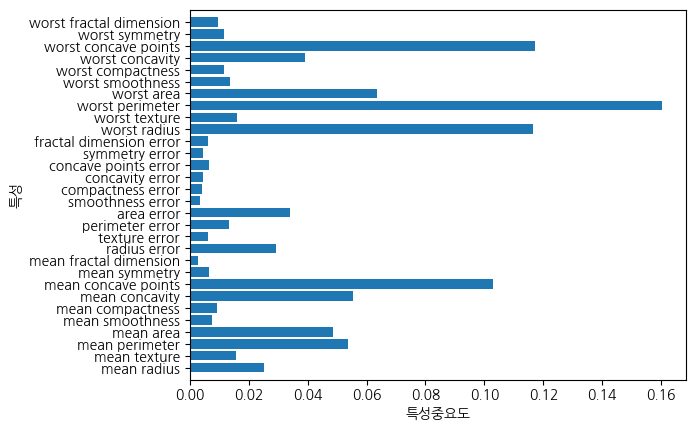

In [114]:
plot_feature(model)

# 유방암 데이터셋을 이용해 그레이디언트부스팅
- 그레이디언트 부스팅은 이전 트리의 오차를 보완하는 방식으로 순차적으로 트리를 만듬
- 회귀와 분류 모두에 사용 가능
- 그레이디언트 부스팅은 회귀트리에는 무작위성이 없음 대신 강력한 가지치기를 사용
- 그레이디언트 부스팅은 보통 하나에서 다섯정도의 깊지않은 트리를 사용함
- 메모리 사용이 적고 에측이 빠름
- 가장 중요한 매개변수는 이전트리의 오차를 얼마나 강력하게 보정할 것 인지를 제어하는 learning_rate이다.
- 학습률이 크면 트리보정을 강하게 하기 때문에 복잡한 모델을 만듬
- n_estimators값을 키우면 앙상블에 트리가 더 많이 추가되어 모델의 복잡도가 커지고 모델의 실수를 바로잡을 수 있음

In [132]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ana
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [133]:
data = load_breast_cancer()
x = data.data
y = data.target

In [134]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [135]:
gbrt = GradientBoostingClassifier(random_state=0)
gbrt.fit(X_train,y_train)

GradientBoostingClassifier(random_state=0)

In [136]:
print('훈련세트 정확도 :', gbrt.score(x_train,y_train))
print('테스트세트 정확도 : ', gbrt.score(x_test,y_test))

훈련세트 정확도 : 1.0
테스트세트 정확도 :  0.965034965034965


In [137]:
gbrt = GradientBoostingClassifier(random_state=0,max_depth=1)
gbrt.fit(X_train,y_train)
print('훈련세트 정확도 :', gbrt.score(x_train,y_train))
print('테스트세트 정확도 : ', gbrt.score(x_test,y_test))

훈련세트 정확도 : 0.9906103286384976
테스트세트 정확도 :  0.972027972027972


In [139]:
gbrt = GradientBoostingClassifier(random_state=0,learning_rate=0.01)
gbrt.fit(X_train,y_train)
print('훈련세트 정확도 :', gbrt.score(x_train,y_train))
print('테스트세트 정확도 : ', gbrt.score(x_test,y_test))

훈련세트 정확도 : 0.9882629107981221
테스트세트 정확도 :  0.958041958041958


In [ ]:
gbrt = GradientBoostingClassifier(random_state=0,max_depth=1)
gbrt.fit(X_train,y_train)
print('훈련세트 정확도 :', gbrt.score(x_train,y_train))
print('테스트세트 정확도 : ', gbrt.score(x_test,y_test))

In [140]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

def plot_feature(model):
  n_features = data.data.shape[1]
  plt.barh(np.arange(n_features),model.feature_importances_,align='center')
  plt.yticks(np.arange(n_features),data.feature_names)
  plt.xlabel('특성중요도')
  plt.ylabel('특성')
  plt.ylim(-1,n_features)

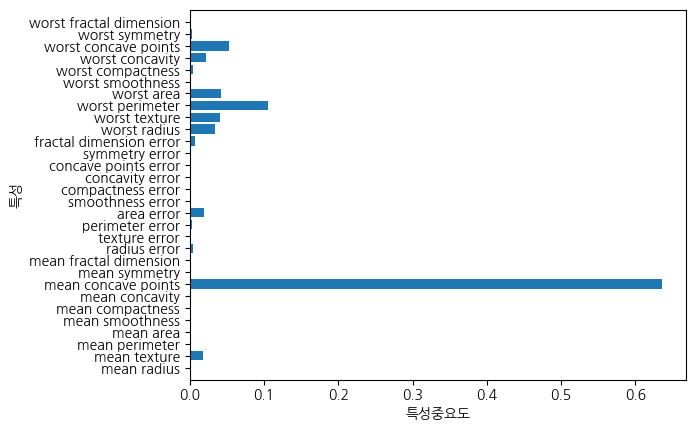

In [141]:
plot_feature(gbrt)

# 유방암 데이터셋을 이용해 엑스트라 트리 구현하기
- 랜덤포레스트와 비슷하지만 후보 특성을 무작위로 분할한 다음 최적의 분할을 찾음
- 부트스트랩 샘플링(중복된 훈련샘플)을 사용하지 않음
- 엑스트라 트리는 split할 때 무작위로 feature를 선정
- 랜덤포레스트보다 속도가 3배 정도 빠름
- 한마디로

In [169]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ana
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [170]:
data = load_breast_cancer()
x = data.data
y = data.target

In [171]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [172]:
Xtree = ExtraTreesClassifier(n_estimators=100, n_jobs=1, random_state=0)
Xtree.fit(X_train, y_train)

ExtraTreesClassifier(n_jobs=1, random_state=0)

In [174]:
print('훈련세트 정확도 :', Xtree.score(x_train,y_train))
print('테스트세트 정확도 : ', Xtree.score(x_test,y_test))

훈련세트 정확도 : 1.0
테스트세트 정확도 :  0.972027972027972


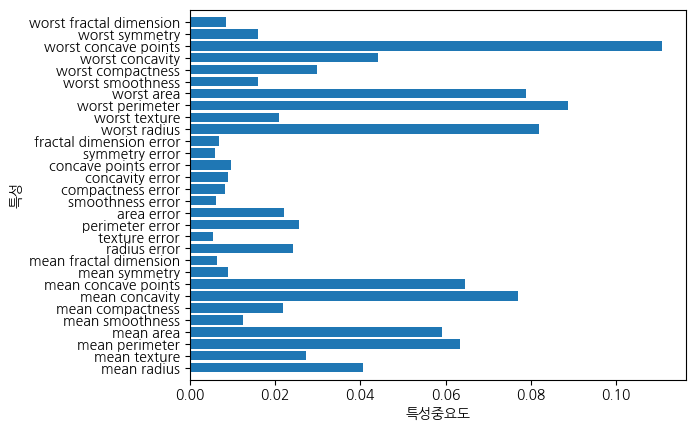

In [162]:
plot_feature(Xtree)

# 유방암 데이터셋을 이용해 에이다부스트
- 그레이디언트 부스팅처럼 약한 학습기를 사용
- 그레이디언트 부스팅과는 달리 이전의 모델이 잘못분류한 샘플에 가중치를 높여서 다음 모델 훈련을 시킴
- 훈련한 각 모델은 성능에 따라 가중치가 부여
- 예측을 만들 때는 모델이 예측한 레이블을 기준으로 모델의 가중치를 합산하여 가장 높은 값을 가진 레이블을 선택

In [184]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ana
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [185]:
data = load_breast_cancer()
x = data.data
y = data.target

In [186]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [187]:
ada = AdaBoostClassifier(n_estimators=100,random_state=42)
ada.fit(X_train, y_train)

AdaBoostClassifier(n_estimators=100, random_state=42)

In [188]:
print('훈련세트 정확도 :', ada.score(x_train,y_train))
print('테스트세트 정확도 : ', ada.score(x_test,y_test))

훈련세트 정확도 : 1.0
테스트세트 정확도 :  0.972027972027972


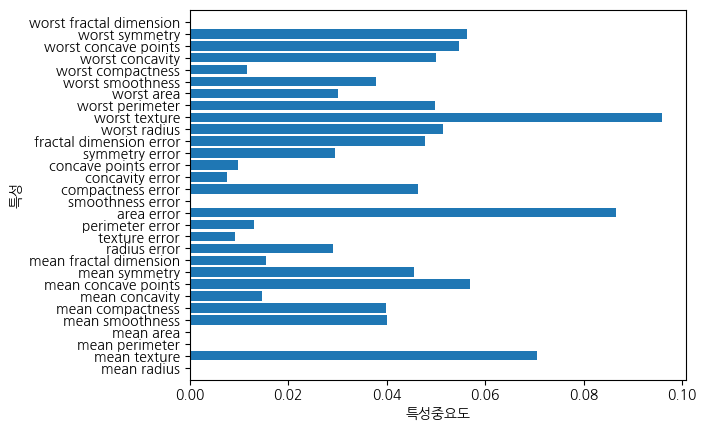

In [189]:
plot_feature(ada)

# 유방암 데이터셋을 이용해 히스토그램기반 부스팅
- 연속형 데이터를 구간(bin)으로 나누는 특징을 가짐
- 트리분활을 빠르게 수행하는 그레디언트 부스팅
- 대규모 데이터에 강함
- 256개의 구간으로 나눔
- 256개의 구간중 하나를 누락된 값을 위해 사용하기 때문에 누락된 값을 전처리할 필요x
- 샘플개수가 만개 이상인 경우, 그레이디언트 부스팅보다 훨씬 빠름

In [190]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as ana
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [191]:
data = load_breast_cancer()
x = data.data
y = data.target

In [192]:
X_train,X_test,y_train,y_test = train_test_split(x,y,random_state=0)

In [193]:
hgb = HistGradientBoostingClassifier(random_state=42)
hgb.fit(X_train, y_train)

HistGradientBoostingClassifier(random_state=42)

In [194]:
print('훈련세트 정확도 :', hgb.score(x_train,y_train))
print('테스트세트 정확도 : ', hgb.score(x_test,y_test))

훈련세트 정확도 : 1.0
테스트세트 정확도 :  0.9790209790209791
